In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.decomposition import PCA
import json

import sys
import os
sys.path.append(os.path.abspath('../'))
from src.word2vec_tensorflow import Word2VecTF, Word2VecTFSequence
from src.data_pipeline import load_corpus, generate_training_data

In [3]:
corpus = load_corpus("../data/processed/toy_corpus.txt")
with open('../data/processed/vocab.json','r',encoding='utf-8') as f:
    vocab=json.load(f)
word2id=vocab['word2id']
id2word=vocab['id2word']
training_data=generate_training_data(corpus,word2id)

In [4]:
targets_array=np.array([pair[0] for pair in training_data])
contexts_array=np.array([pair[1] for pair in training_data])

In [10]:
vocab_size=len(word2id)
tf_dataloader=Word2VecTFSequence(targets_array,contexts_array,batch_size=128)
model_tf=Word2VecTF(vocab_size=vocab_size,embedding_dim=30)

model_tf.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
)

In [11]:
model_tf.fit(tf_dataloader,epochs=100)

Epoch 1/100
232/232 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 6.8118
Epoch 2/100
232/232 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5.8689
Epoch 3/100
232/232 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 5.2247
Epoch 4/100
232/232 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 4.7827
Epoch 5/100
232/232 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 4.5146
Epoch 6/100
232/232 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 4.3530
Epoch 7/100
232/232 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 4.2550
Epoch 8/100
232/232 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 4.1783
Epoch 9/100
232/232 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 4.1287
Epoch 10/100
232/232 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 4.0862
Epoch 11/100
232/232 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 4.0618
Epoch 12/100
232/232 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 4.0332
Epoch 13/100
232/232 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 4.0133
Epoch 14/100
232/232 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 4.0000
Epoch 15/100
232/232 ━━━━━━━━━━━━━━━━━━

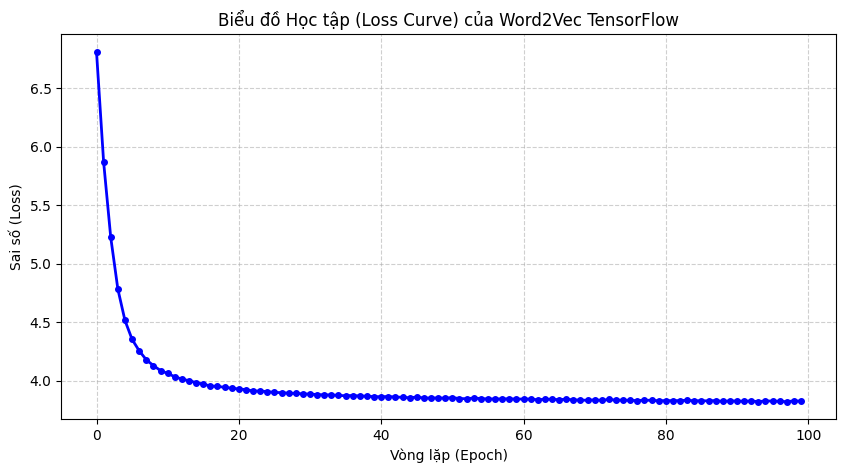

In [12]:
loss_his=model_tf.history.history['loss']

plt.figure(figsize=(10, 5))
plt.plot(loss_his, color='blue', linewidth=2, marker='o', markersize=4)
plt.title('Biểu đồ Học tập (Loss Curve) của Word2Vec TensorFlow')
plt.xlabel('Vòng lặp (Epoch)')
plt.ylabel('Sai số (Loss)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [18]:
id2word = {int(k): v for k, v in vocab['id2word'].items()}

print("TÌM TỪ ĐỒNG NGHĨA VỚI 'ký_túc_xá'")
similar_words = model_tf.get_similar_words(word_id=0, top=3, id2word=id2word)
for word, sim_score in similar_words:
    print(f" -> Từ liên quan: {word} (Độ tương đồng: {sim_score*100:.1f}%)")

TÌM TỪ ĐỒNG NGHĨA VỚI 'ký_túc_xá'
 -> Từ liên quan: tọa_lạc (Độ tương đồng: 63.0%)
 -> Từ liên quan: bệnh (Độ tương đồng: 59.2%)
 -> Từ liên quan: nội_bộ (Độ tương đồng: 55.0%)


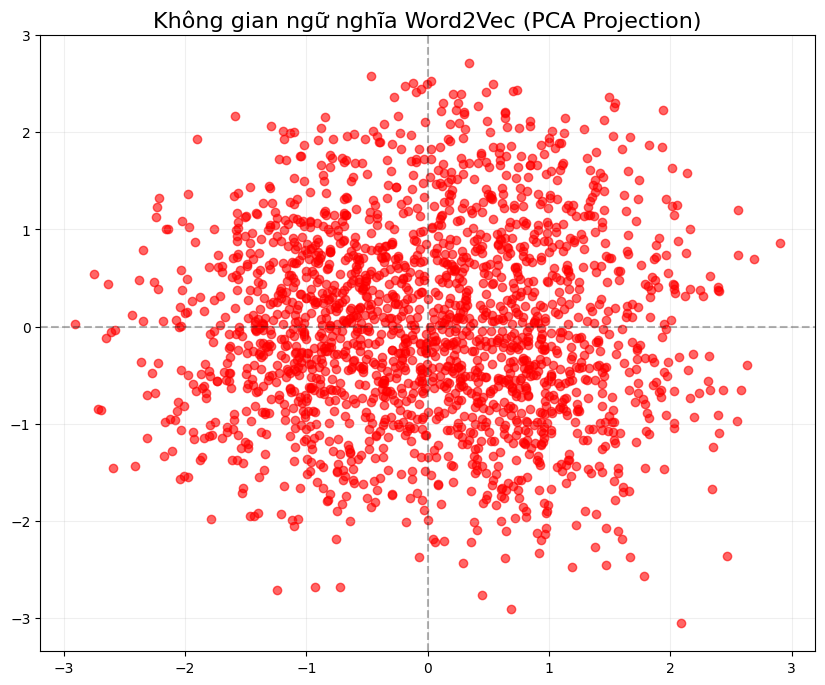

In [17]:
def visualize_embeddings(model, id2word):
    embeddings = model.W1.get_weights()[0]
    pca = PCA(n_components=2)
    embeddings_2d = pca.fit_transform(embeddings)
    plt.figure(figsize=(10, 8))

    for word_id, word in id2word.items():
        x, y = embeddings_2d[word_id]
        plt.scatter(x, y, color='red', alpha=0.6)
        #plt.text(x + 0.02, y + 0.02, word, fontsize=12)

    plt.title("Không gian ngữ nghĩa Word2Vec (PCA Projection)", fontsize=16)
    plt.axhline(y=0, color='k', linestyle='--', alpha=0.3)
    plt.axvline(x=0, color='k', linestyle='--', alpha=0.3)
    plt.grid(True, alpha=0.2)
    plt.show()

visualize_embeddings(model_tf, id2word)